# 2. Auditoría y Validación de Datos (Sustituto de EDA)

A diferencia de un Análisis Exploratorio de Datos tradicional (donde buscamos patrones desconocidos), este cuaderno actúa como un **control de calidad**. Su propósito es auditar que el dataset sintético generado en el Cuaderno 1 cumpla con las propiedades estadísticas deseadas antes de entrenar el modelo.

In [1]:
# =============================================================================
# 1. CARGA DE LIBRERIAS Y LECTURA DE LOS DATASETS SINTETICOS
# =============================================================================
import warnings

# Desactivamos advertencias menores para mantener las salidas visuales limpias
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuramos el estilo visual con rejilla blanca
sns.set_theme(style="whitegrid")

# Cargamos los archivos generados en la fase de simulacion (Cuaderno 1)
df_t = pd.read_csv('data/transacciones.csv')  # Dataset de transacciones para NLP
df_u = pd.read_csv('data/usuarios.csv')       # Dataset demografico para perfilado financiero
print("Datos cargados correctamente en memoria. Iniciando auditoría estadística.")


Datos cargados correctamente en memoria. Iniciando auditoría estadística.


## 2.1 Validación de Partición Temporal (Out-of-Time)
Comprobamos que las transacciones de validación y prueba ocurran estrictamente en meses posteriores al entrenamiento.

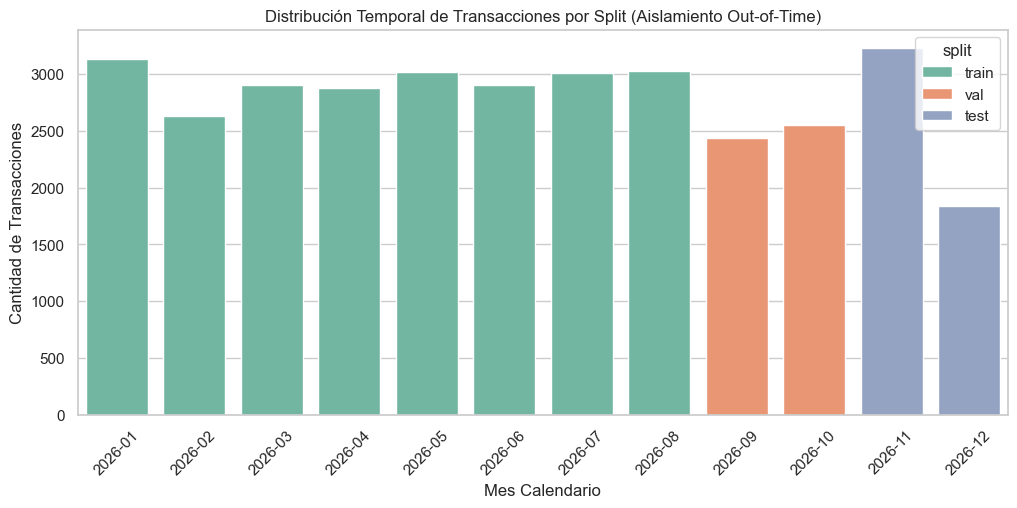

In [2]:
# =============================================================================
# 2. AUDITORIA DE PARTICION TEMPORAL (OUT-OF-TIME VALIDATION)
# =============================================================================
# Convertimos la columna 'fecha' a formato datetime nativo de Pandas para operaciones cronologicas
df_t['fecha'] = pd.to_datetime(df_t['fecha'])

# Agrupamos las fechas por periodo mensual (ej. '2026-01', '2026-02') para graficar por mes
df_t['mes'] = df_t['fecha'].dt.to_period('M')

plt.figure(figsize=(12, 5))
# Graficamos la cantidad de transacciones por mes, coloreando segun el 'split' asignado (train, val, test)
sns.countplot(data=df_t.sort_values('mes'), x='mes', hue='split', palette='Set2')
plt.title('Distribución Temporal de Transacciones por Split (Aislamiento Out-of-Time)')
plt.xlabel('Mes Calendario')
plt.ylabel('Cantidad de Transacciones')
plt.xticks(rotation=45)  # Rotamos etiquetas del eje X para facilitar la lectura
plt.show()


## 2.2 Auditoría de Colinealidad (Solapamiento de Montos)
En la v1, los montos permitían deducir la categoría casi al 100%. Verificamos visualmente que en esta v2 los montos se solapen fuertemente, forzando al modelo a aprender el texto.

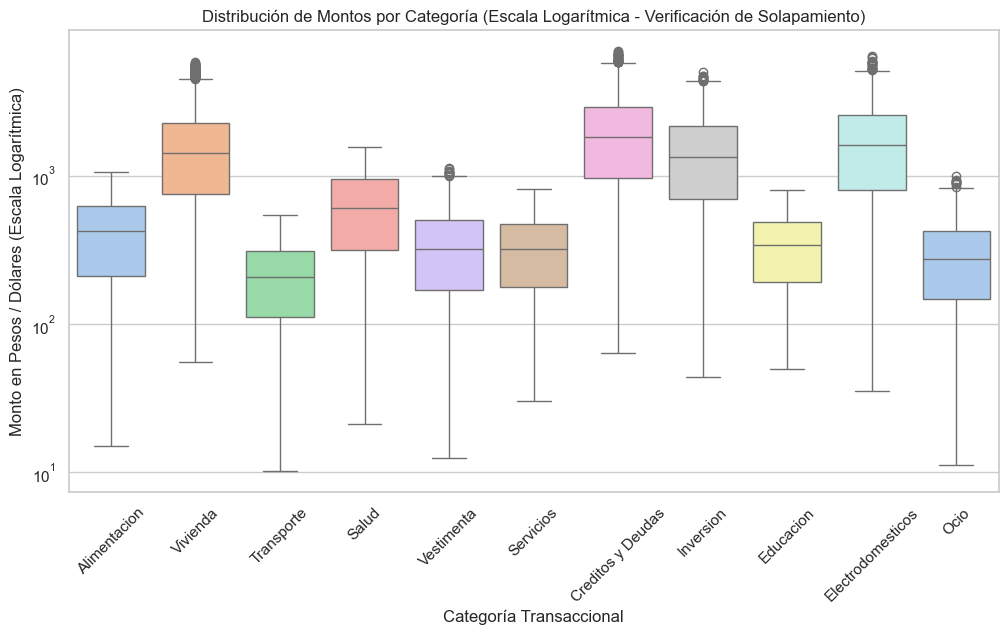

In [3]:
# =============================================================================
# 3. AUDITORIA DE COLINEALIDAD: DISTRIBUCION DE MONTOS POR CATEGORIA
# =============================================================================
plt.figure(figsize=(12, 6))
# El diagrama de caja (Boxplot) permite ver la mediana, cuartiles y dispersion de montos por categoria
sns.boxplot(data=df_t, x='categoria', y='monto', palette='pastel')

# Usamos escala logaritmica en el eje Y para visualizar adecuadamente diferencias entre montos pequenos ($15) y grandes ($3000)
plt.yscale('log')
plt.title('Distribución de Montos por Categoría (Escala Logarítmica - Verificación de Solapamiento)')
plt.xlabel('Categoría Transaccional')
plt.ylabel('Monto en Pesos / Dólares (Escala Logarítmica)')
plt.xticks(rotation=45)
plt.show()


## 2.3 Diversidad Léxica y Ambigüedad
Auditamos la longitud y el ruido en las descripciones.

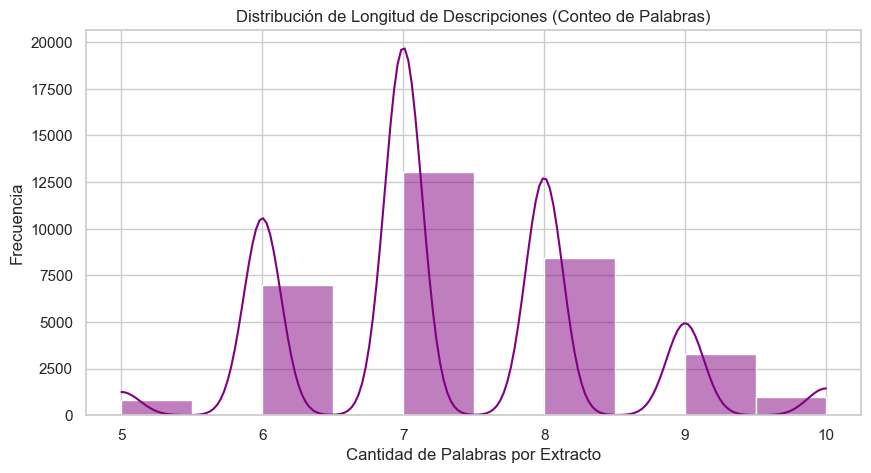

Muestras de extractos bancarios con ruido sintetico (prefijos POS, sufijos y Leetspeak):


,descripcion,categoria
23972,E-COMMERCE EXPENSAS CONSORCIO MENDOZA *4530 RE...,Vivienda
32262,PAGO QR VERDULERIA Y FRUTERIA MENDOZA *9047 RE...,Alimentacion
3974,E-COMMERCE DEBITO AUTOMATICO CABA *5775 REF:42...,Servicios
5941,E-COMMERCE PANADERIA ARTESANAL CABA *2362 REF:...,Alimentacion
24548,PAGO QR MERCADO LIBRE ROSARIO *3116 REF:986196,Electrodomesticos


In [4]:
# =============================================================================
# 4. DIVERSIDAD LEXICA, LONGITUD Y RUIDO SINTETICO EN DESCRIPCIONES
# =============================================================================
# Calculamos la cantidad de palabras por descripcion dividiendo por espacios en blanco
df_t['longitud'] = df_t['descripcion'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
# Graficamos la distribucion de longitudes de palabras con KDE
sns.histplot(data=df_t, x='longitud', bins=10, kde=True, color='purple')
plt.title('Distribución de Longitud de Descripciones (Conteo de Palabras)')
plt.xlabel('Cantidad de Palabras por Extracto')
plt.ylabel('Frecuencia')
plt.show()

# Mostramos 5 ejemplos aleatorios de transacciones que contienen ruido (numeros, Leetspeak o prefijos POS/AUT)
print("Muestras de extractos bancarios con ruido sintetico (prefijos POS, sufijos y Leetspeak):")
display(df_t[df_t['descripcion'].str.contains('0|3|4|POS|AUT', regex=True)].sample(5)[['descripcion', 'categoria']])


## 2.4 Auditoría de Ambigüedad (Tokens Compartidos)
Comprobamos empíricamente que ciertas palabras clave existan en múltiples categorías, rompiendo la posibilidad de un 'lookup' trivial.

In [5]:
# =============================================================================
# 5. AUDITORIA DE AMBIGUEDAD REAL (TOKENS COMPARTIDOS ENTRE CATEGORIAS)
# =============================================================================
# Palabras clave que verificaremos si aparecen en multiples categorias para romper el memorismo del modelo
ambiguos = ['farmacity', 'suscripcion', 'mercado', 'cuota', 'transferencia']

print("Presencia cruzada de tokens ambiguos por categoría (Rompe la exclusividad léxica):\n")
for kw in ambiguos:
    # Creamos una mascara booleana para filtrar descripciones que contengan la palabra clave en minusculas
    mask = df_t['descripcion'].str.lower().str.contains(kw, na=False)
    if mask.sum() > 0:
        # Obtenemos el conteo de ocurrencias agrupado por categoria real
        conteo = df_t[mask]['categoria'].value_counts().to_dict()
        print(f"Token '{kw.upper()}': {conteo}")


Presencia cruzada de tokens ambiguos por categoría (Rompe la exclusividad léxica):

Token 'FARMACITY': {'Alimentacion': 816, 'Salud': 350}
Token 'SUSCRIPCION': {'Ocio': 267, 'Educacion': 219, 'Servicios': 182}
Token 'MERCADO': {'Alimentacion': 1903, 'Electrodomesticos': 428, 'Vestimenta': 378, 'Ocio': 105}
Token 'CUOTA': {'Creditos y Deudas': 757, 'Vivienda': 493, 'Educacion': 404, 'Servicios': 185}
Token 'TRANSFERENCIA': {'Vivienda': 1659, 'Alimentacion': 1310, 'Servicios': 893, 'Creditos y Deudas': 869, 'Inversion': 806, 'Transporte': 556, 'Educacion': 362, 'Salud': 298, 'Vestimenta': 288, 'Electrodomesticos': 248, 'Ocio': 231}


## 2.5 Validación de Usuarios (Perfilador Financiero)
Verificamos la distribución de usuarios y sus perfiles de riesgo generados por lógica difusa.

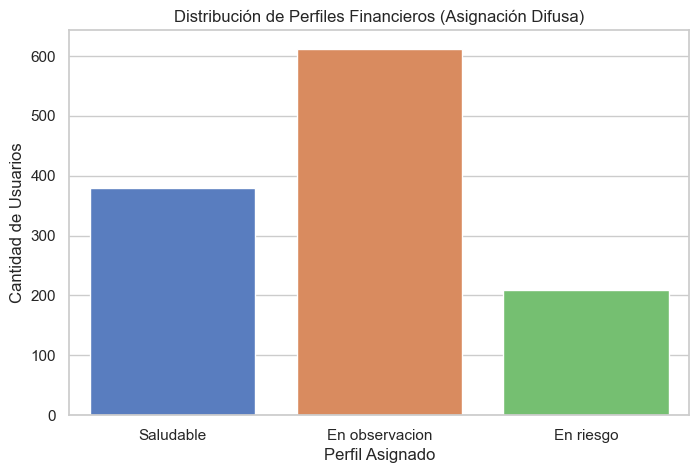


Estadísticas descriptivas del Score de Riesgo Oculto por Perfil:


,count,mean,min,max
perfil_financiero,,,,
En observacion,612.0,0.464801,0.330047,0.599412
En riesgo,209.0,0.672092,0.600100,0.837988
Saludable,379.0,0.227328,0.030550,0.329508


In [6]:
# =============================================================================
# 6. AUDITORIA DE PERFILES FINANCIEROS Y DISTRIBUCION DIFUSA
# =============================================================================
plt.figure(figsize=(8, 5))
# Graficamos el conteo de usuarios clasificados en cada categoria de perfil financiero
sns.countplot(
    data=df_u,
    x='perfil_financiero',
    order=['Saludable', 'En observacion', 'En riesgo'],
    palette='muted'
)
plt.title('Distribución de Perfiles Financieros (Asignación Difusa)')
plt.xlabel('Perfil Asignado')
plt.ylabel('Cantidad de Usuarios')
plt.show()

print("\nEstadísticas descriptivas del Score de Riesgo Oculto por Perfil:")
# Verificamos las medias, minimos y maximos para comprobar que existen zonas grises bien balanceadas
display(df_u.groupby('perfil_financiero')['score_riesgo_oculto'].describe()[['count', 'mean', 'min', 'max']])


## 2.6 Conclusión de Auditoría
El dataset sintético ha sido validado. La ambigüedad cruzada funciona, el desbalance de clases es realista, y los perfiles financieros mantienen fronteras difusas (ruido gaussiano), garantizando que el modelo no dependa de una colinealidad perfecta.

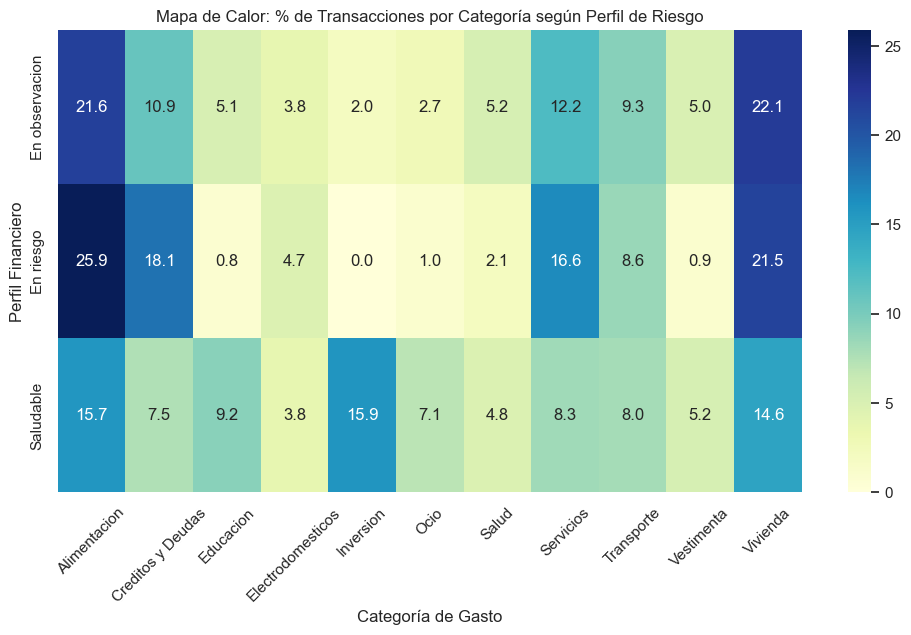

Auditoría: Observamos que usuarios 'En riesgo' gastan casi 0% en Inversión y más en Alimentación/Servicios, validando el realismo del generador.


In [7]:
# =============================================================================
# 7. AUDITORIA DE COMPORTAMIENTO (PERFIL vs GASTO)
# =============================================================================
# Unimos las transacciones con la demografía del usuario para verificar la hipótesis conductual
df_merged = pd.merge(df_t, df_u[['id', 'perfil_financiero']], left_on='usuario_id', right_on='id')

plt.figure(figsize=(12, 6))
# Graficamos la proporción de gasto por categoría según el perfil del usuario
gasto_perfil = df_merged.groupby(['perfil_financiero', 'categoria']).size().unstack(fill_value=0)
# Normalizamos por fila para obtener el % de gasto relativo por perfil
gasto_perfil_pct = gasto_perfil.div(gasto_perfil.sum(axis=1), axis=0) * 100

sns.heatmap(gasto_perfil_pct, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Mapa de Calor: % de Transacciones por Categoría según Perfil de Riesgo')
plt.ylabel('Perfil Financiero')
plt.xlabel('Categoría de Gasto')
plt.xticks(rotation=45)
plt.show()

print("Auditoría: Observamos que usuarios 'En riesgo' gastan casi 0% en Inversión y más en Alimentación/Servicios, validando el realismo del generador.")
